In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
scada = pd.read_csv("T1.csv")

In [37]:
# feature engineering part
# 1) month and hour
scada["Date/Time"] = pd.to_datetime(scada["Date/Time"], errors='coerce')
scada["month"] = scada["Date/Time"].dt.month
scada["hour"] = scada["Date/Time"].dt.hour

# 2) wind power density (since elevation in NL doesnt exceed 500m, we can take error as +- 4.7%)
scada["wind_power_density"] = 0.5 * 1.225 * scada["Wind Speed (m/s)"]**3   # W/m^2

# 3) actual output / maximum output
scada["capacity_factor"] = scada["LV ActivePower (kW)"] / 2050

# 4) efficency (how close actual power is to theoretical)
theoretical = scada["Theoretical_Power_Curve (KWh)"]
actual = scada["LV ActivePower (kW)"]
scada["power_efficiency"] = (actual / theoretical).where(theoretical > 10)

# 5) wind direction components (for model training)
scada["dir_sin"] = np.sin(np.radians(scada["Wind Direction (°)"]))
scada["dir_cos"] = np.cos(np.radians(scada["Wind Direction (°)"]))

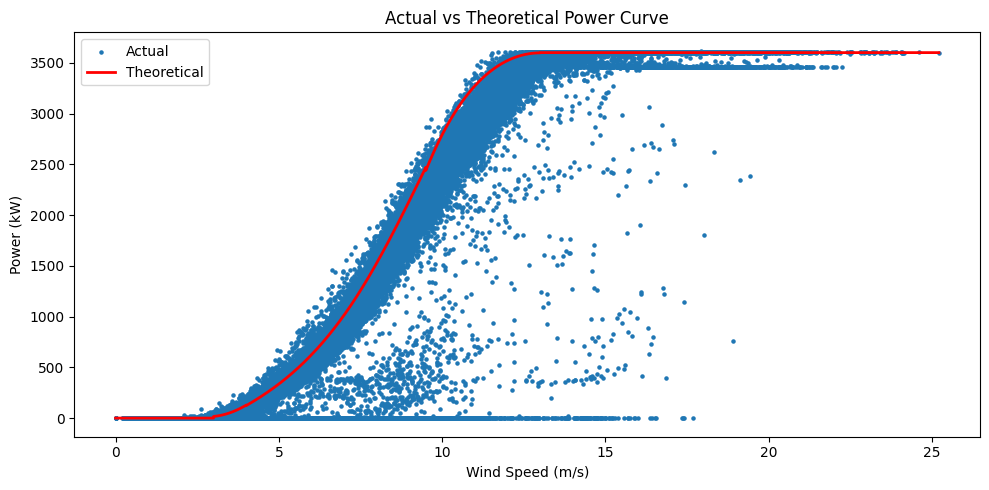

In [38]:
# Power curve
fig, ax = plt.subplots(figsize=(10, 5))

# the actual scatter
ax.scatter(scada["Wind Speed (m/s)"], scada["LV ActivePower (kW)"], s=5, label="Actual")

# theoretical line
theo = theo.sort_values("Wind Speed (m/s)")
ax.plot(theo["Wind Speed (m/s)"], theo["Theoretical_Power_Curve (KWh)"], color="red", linewidth=2, label="Theoretical")

ax.set_xlabel("Wind Speed (m/s)")
ax.set_ylabel("Power (kW)")
ax.set_title("Actual vs Theoretical Power Curve")
ax.legend()
plt.tight_layout()
plt.show()

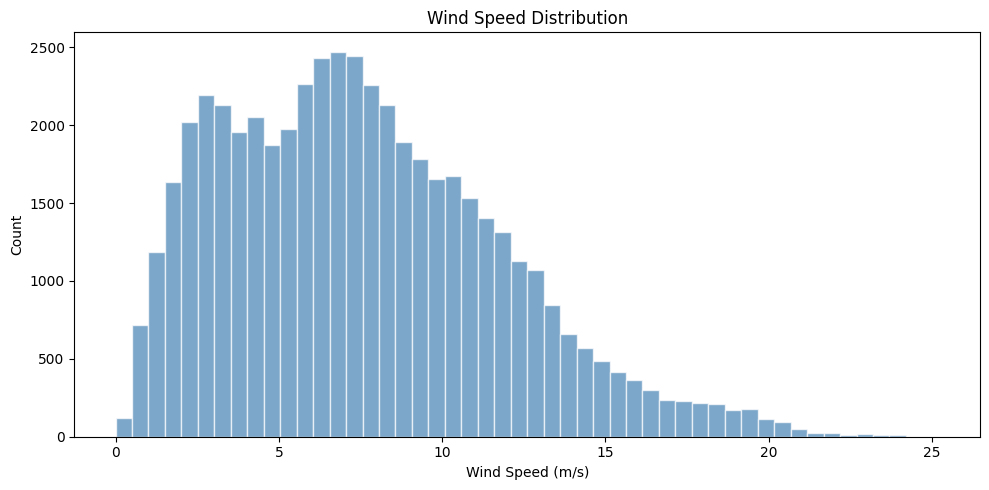

In [39]:
# wind distribution
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(scada["Wind Speed (m/s)"].dropna(), bins=50, color="steelblue", alpha=0.7, edgecolor="white")

ax.set_xlabel("Wind Speed (m/s)")
ax.set_ylabel("Count")
ax.set_title("Wind Speed Distribution")
plt.tight_layout()
plt.show()

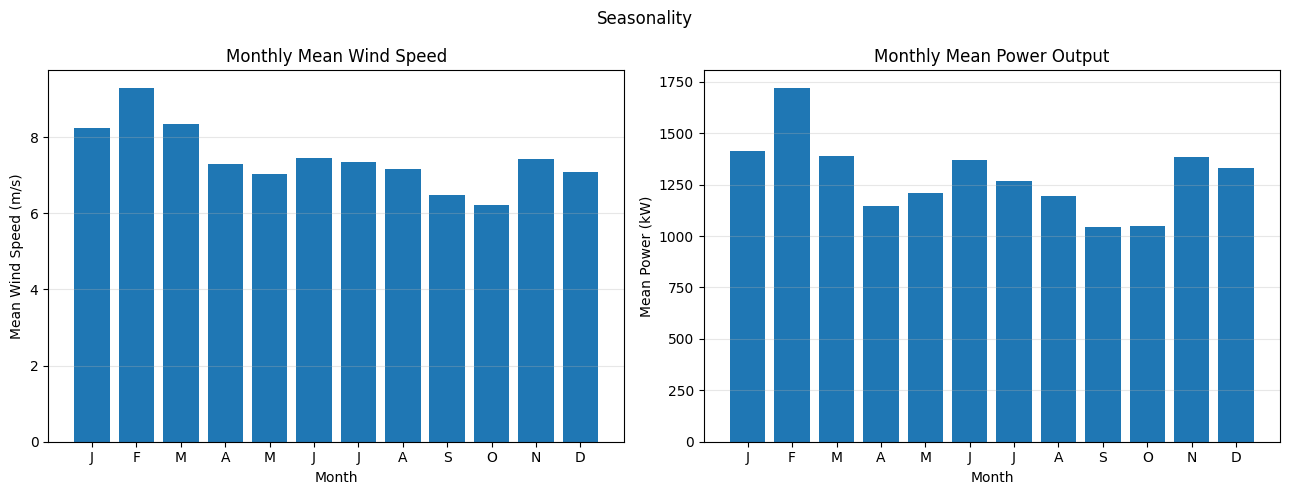

In [40]:
# seasonality
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Seasonality")

ax = axes[0]
monthly_ws = scada.groupby("month")["Wind Speed (m/s)"].mean()
ax.bar(monthly_ws.index, monthly_ws.values, linewidth=0.3)
ax.set_xlabel("Month")
ax.set_ylabel("Mean Wind Speed (m/s)")
ax.set_title("Monthly Mean Wind Speed")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
monthly_power = scada.groupby("month")["LV ActivePower (kW)"].mean()
ax.bar(monthly_power.index, monthly_power.values, linewidth=0.3)
ax.set_xlabel("Month")
ax.set_ylabel("Mean Power (kW)")
ax.set_title("Monthly Mean Power Output")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

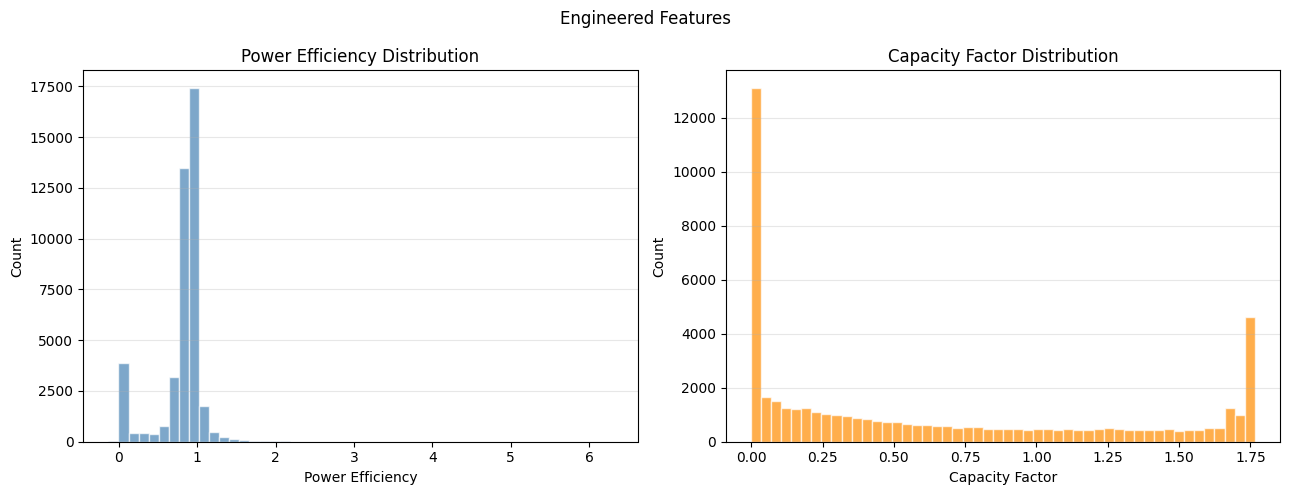

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Engineered Features")

axes[0].hist(scada["power_efficiency"].dropna(), bins=50, color="steelblue", edgecolor="white", alpha=0.7)
axes[0].set_xlabel("Power Efficiency")
axes[0].set_ylabel("Count")
axes[0].set_title("Power Efficiency Distribution")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(scada["capacity_factor"].dropna(), bins=50, color="darkorange", edgecolor="white", alpha=0.7)
axes[1].set_xlabel("Capacity Factor")
axes[1].set_ylabel("Count")
axes[1].set_title("Capacity Factor Distribution")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()